In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. Cargar el dataset limpio
ruta_csv = '../Bases de datos/DatasetDefinitivo_2310indep.csv'
df = pd.read_csv(ruta_csv, delimiter=',', encoding='ISO-8859-1')

# 2. Definir los parámetros de la discretización
# Ajusta el rango min y max según los límites físicos reales de tus moléculas
lambda_min = 200 # Límite inferior en nm
lambda_max = 600 # Límite superior en nm
puntos_resolucion = 100 # Empezamos con 100 puntos de resolución

# Creamos el eje X (longitudes de onda)
eje_x_nm = np.linspace(lambda_min, lambda_max, puntos_resolucion)

In [3]:
# 3. Definir la función Gaussiana
def gaussiana(x, amplitud, centro, sigma):
    """Calcula una curva gaussiana sobre el vector x."""
    return amplitud * np.exp(-((x - centro) ** 2) / (2 * sigma ** 2))

In [4]:
# 4. Función para generar el espectro completo de una molécula
def generar_espectro_molecula(fila, eje_x, sigma_ev=0.2): # Cambiamos sigma fija por valor en eV
    # Inicializamos el espectro a 0
    espectro = np.zeros_like(eje_x)
    
    # Función auxiliar para calcular la sigma en nm según la energía constante
    # sigma_nm = (lambda^2 / 1240) * sigma_ev
    def calc_sigma(lambda_nm):
        return (lambda_nm**2 / 1240) * sigma_ev

    # Sumamos la contribución del pico R1
    if pd.notna(fila['nm_R1']) and pd.notna(fila['R1']):
        s = calc_sigma(fila['nm_R1'])
        espectro += gaussiana(eje_x, fila['R1'], fila['nm_R1'], s)
        
    # Sumamos la contribución del pico Rmin
    if pd.notna(fila['nm_Rmin']) and pd.notna(fila['Rmin']):
        s = calc_sigma(fila['nm_Rmin'])
        espectro += gaussiana(eje_x, fila['Rmin'], fila['nm_Rmin'], s)
        
    # Sumamos la contribución del pico Rmax
    if pd.notna(fila['nm_Rmax']) and pd.notna(fila['Rmax']):
        s = calc_sigma(fila['nm_Rmax'])
        espectro += gaussiana(eje_x, fila['Rmax'], fila['nm_Rmax'], s)
        
        
    return espectro

In [5]:
# --- PRUEBA VISUAL ---
# Vamos a probar la función con la primera molécula del dataset
fila_prueba = df.iloc[0]
espectro_prueba = generar_espectro_molecula(fila_prueba, eje_x_nm)

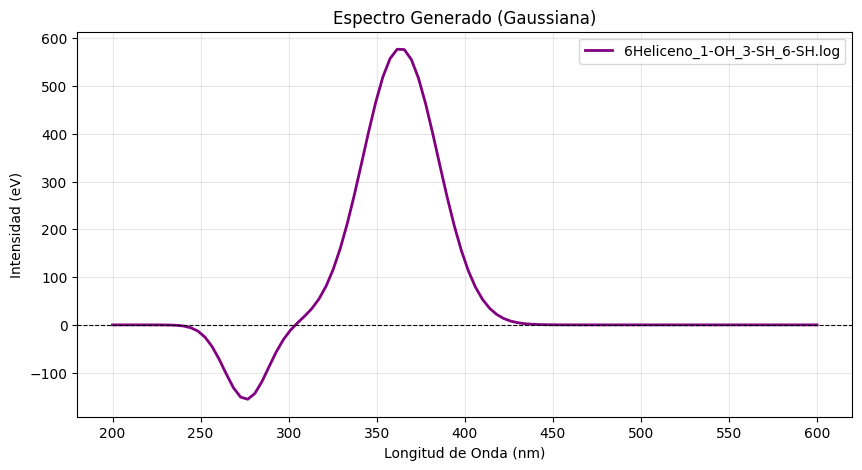

In [7]:

# Graficamos para ver el resultado
plt.figure(figsize=(10, 5))
plt.plot(eje_x_nm, espectro_prueba, label=fila_prueba['Molecula'], color='purple', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # Línea base en 0
plt.xlabel("Longitud de Onda (nm)")
plt.ylabel("Intensidad (eV)")
plt.title("Espectro Generado (Gaussiana)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:

#Descomentar esta sección si quieres ver el espectro sin normalizar
from tqdm import tqdm

# 1. Preparar las listas vacías
espectros_y = [] 
caracteristicas_x = []

# Lista de columnas de posición que actúan como features
position_columns = [f'Pos_{i}' for i in range(1, 17)]

# 2. Iterar sobre todas las moléculas del dataset
for index, fila in tqdm(df.iterrows(), total=df.shape[0], desc="Generando espectros"):
    # Generar el espectro continuo (Salida - Y)
    espectro = generar_espectro_molecula(fila, eje_x_nm)
    espectros_y.append(espectro)
    
    # Extraer los valores de Hammett (Entrada - X)
    posiciones = fila[position_columns].values.astype(float)
    caracteristicas_x.append(posiciones)

# 3. Convertir las listas a matrices de NumPy (Formato nativo para Deep Learning)
X = np.array(caracteristicas_x)
Y = np.array(espectros_y)

print("\n--- ¡Preprocesamiento Finalizado! ---")
print(f"Forma de la matriz X (Entrada): {X.shape} -> (Moléculas, Características)")
print(f"Forma de la matriz Y (Salida) : {Y.shape} -> (Moléculas, Puntos del Espectro)")


Generando espectros: 100%|██████████| 13168/13168 [00:06<00:00, 2186.69it/s]


--- ¡Preprocesamiento Finalizado! ---
Forma de la matriz X (Entrada): (13168, 16) -> (Moléculas, Características)
Forma de la matriz Y (Salida) : (13168, 100) -> (Moléculas, Puntos del Espectro)


In [ ]:
'''#Normalización global de Y
from tqdm import tqdm
import numpy as np

# 1. Preparar las listas vacías
espectros_y_crudos = [] 
caracteristicas_x = []

# Lista de columnas de posición que actúan como features
position_columns = [f'Pos_{i}' for i in range(1, 17)]

# 2. Iterar sobre todas las moléculas para generar espectros en escala real
# Nota: Asegúrate de que 'generar_espectro_molecula' ya NO contenga la división por el máximo individual
for index, fila in tqdm(df.iterrows(), total=df.shape[0], desc="Generando espectros"):
    # Generar el espectro continuo sin normalización interna
    espectro = generar_espectro_molecula(fila, eje_x_nm)
    espectros_y_crudos.append(espectro)
    
    # Extraer los valores de Hammett (Entrada - X)
    posiciones = fila[position_columns].values.astype(float)
    caracteristicas_x.append(posiciones)

# 3. Convertir a matrices de NumPy
X = np.array(caracteristicas_x)
Y_raw = np.array(espectros_y_crudos)

# === 4. APLICAR NORMALIZACIÓN GLOBAL ===
# Encontramos el valor máximo absoluto considerando todos los puntos de todas las moléculas
valor_max_global = np.max(np.abs(Y_raw))

# Escalamos toda la matriz por este factor único
Y = Y_raw / valor_max_global

print("\n--- ¡Preprocesamiento Finalizado con Normalización Global! ---")
print(f"Valor máximo absoluto detectado en el dataset: {valor_max_global:.4f}")
print(f"Forma de la matriz X (Entrada): {X.shape} -> (Moléculas, Características)")
print(f"Forma de la matriz Y (Salida) : {Y.shape} -> (Moléculas, Puntos del Espectro)")
print(f"Rango de valores en Y: [{Y.min():.2f}, {Y.max():.2f}]")'''

'#Normalización global de Y\nfrom tqdm import tqdm\nimport numpy as np\n\n# 1. Preparar las listas vacías\nespectros_y_crudos = [] \ncaracteristicas_x = []\n\n# Lista de columnas de posición que actúan como features\nposition_columns = [f\'Pos_{i}\' for i in range(1, 17)]\n\n# 2. Iterar sobre todas las moléculas para generar espectros en escala real\n# Nota: Asegúrate de que \'generar_espectro_molecula\' ya NO contenga la división por el máximo individual\nfor index, fila in tqdm(df.iterrows(), total=df.shape[0], desc="Generando espectros"):\n    # Generar el espectro continuo sin normalización interna\n    espectro = generar_espectro_molecula(fila, eje_x_nm)\n    espectros_y_crudos.append(espectro)\n\n    # Extraer los valores de Hammett (Entrada - X)\n    posiciones = fila[position_columns].values.astype(float)\n    caracteristicas_x.append(posiciones)\n\n# 3. Convertir a matrices de NumPy\nX = np.array(caracteristicas_x)\nY_raw = np.array(espectros_y_crudos)\n\n# === 4. APLICAR NORM

--------------------------------------------------
ANÁLISIS DE PICOS EXTREMOS EN EL ESPECTRO CONTINUO
--------------------------------------------------
La molécula 414 tiene la mayor intensidad POSITIVA.
 -> Este pico ocurre exactamente a los 381.82 nm.
 -> Intensidad normalizada: 1470.0575

La molécula 5301 tiene la mayor intensidad NEGATIVA.
 -> Este pico ocurre exactamente a los 268.69 nm.
 -> Intensidad normalizada: -970.0454
--------------------------------------------------


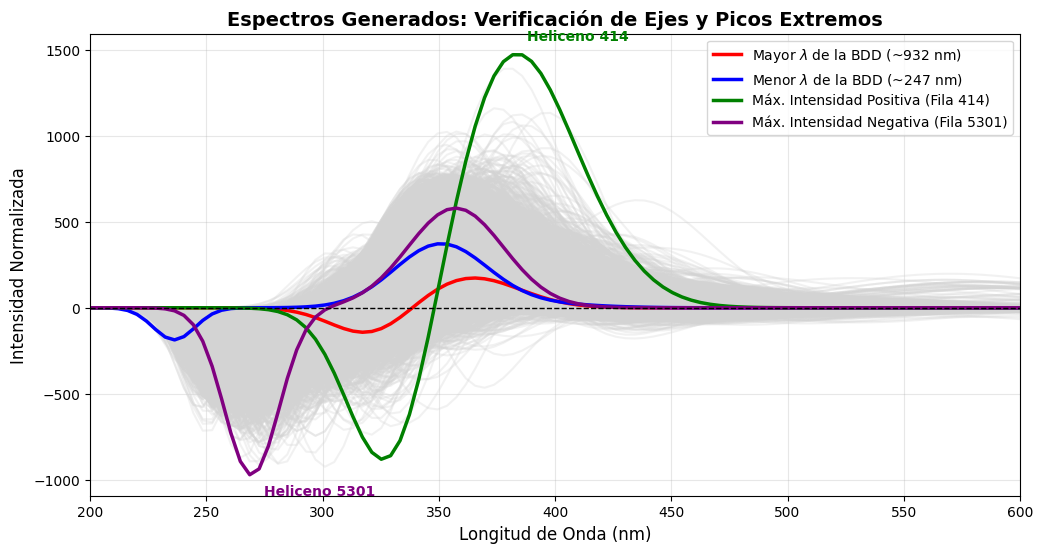

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Identificar los índices de las moléculas con casos extremos
idx_lam_max = df[['nm_R1', 'nm_Rmin', 'nm_Rmax']].max(axis=1).idxmax()
idx_lam_min = df[['nm_R1', 'nm_Rmin', 'nm_Rmax']].min(axis=1).idxmin()

idx_int_max = np.argmax(np.max(Y, axis=1))
idx_int_min = np.argmin(np.min(Y, axis=1))

# --- NUEVO: CALCULAR EN QUÉ LONGITUD DE ONDA CAEN ESTOS PICOS ---
# Buscamos el índice de la matriz Y donde ocurre el pico, y le pedimos a eje_x_nm 
# que nos diga qué longitud de onda corresponde a ese índice.
onda_pico_positivo = eje_x_nm[np.argmax(Y[idx_int_max])]
onda_pico_negativo = eje_x_nm[np.argmin(Y[idx_int_min])]

print("-" * 50)
print("ANÁLISIS DE PICOS EXTREMOS EN EL ESPECTRO CONTINUO")
print("-" * 50)
print(f"La molécula {idx_int_max} tiene la mayor intensidad POSITIVA.")
print(f" -> Este pico ocurre exactamente a los {onda_pico_positivo:.2f} nm.")
print(f" -> Intensidad normalizada: {np.max(Y[idx_int_max]):.4f}\n")

print(f"La molécula {idx_int_min} tiene la mayor intensidad NEGATIVA.")
print(f" -> Este pico ocurre exactamente a los {onda_pico_negativo:.2f} nm.")
print(f" -> Intensidad normalizada: {np.min(Y[idx_int_min]):.4f}")
print("-" * 50)

# 2. Configurar el gráfico
plt.figure(figsize=(12, 6))

for espectro in Y:
    plt.plot(eje_x_nm, espectro, color='lightgray', alpha=0.3)

# 3. Resaltar las curvas de interés
plt.plot(eje_x_nm, Y[idx_lam_max], color='red', linewidth=2.5, 
         label=f'Mayor $\lambda$ de la BDD (~932 nm)')
plt.plot(eje_x_nm, Y[idx_lam_min], color='blue', linewidth=2.5, 
         label=f'Menor $\lambda$ de la BDD (~247 nm)')

if idx_int_max not in [idx_lam_max, idx_lam_min]:
    plt.plot(eje_x_nm, Y[idx_int_max], color='green', linewidth=2.5, 
             label=f'Máx. Intensidad Positiva (Fila {idx_int_max})')
    # --- NUEVA ETIQUETA VISUAL ---
    plt.annotate(f'Heliceno {idx_int_max}', 
                 xy=(onda_pico_positivo, np.max(Y[idx_int_max])), 
                 xytext=(10, 10), textcoords='offset points', 
                 color='green', fontweight='bold')
if idx_int_min not in [idx_lam_max, idx_lam_min]:
    plt.plot(eje_x_nm, Y[idx_int_min], color='purple', linewidth=2.5, 
             label=f'Máx. Intensidad Negativa (Fila {idx_int_min})')
# --- NUEVA ETIQUETA VISUAL ---
    plt.annotate(f'Heliceno {idx_int_min}', 
                 xy=(onda_pico_negativo, np.min(Y[idx_int_min])), 
                 xytext=(10, -15), textcoords='offset points', 
                 color='purple', fontweight='bold')
# Detalles estéticos
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel("Longitud de Onda (nm)", fontsize=12)
plt.ylabel("Intensidad Normalizada", fontsize=12)
plt.title("Espectros Generados: Verificación de Ejes y Picos Extremos", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(lambda_min, lambda_max)
plt.show()

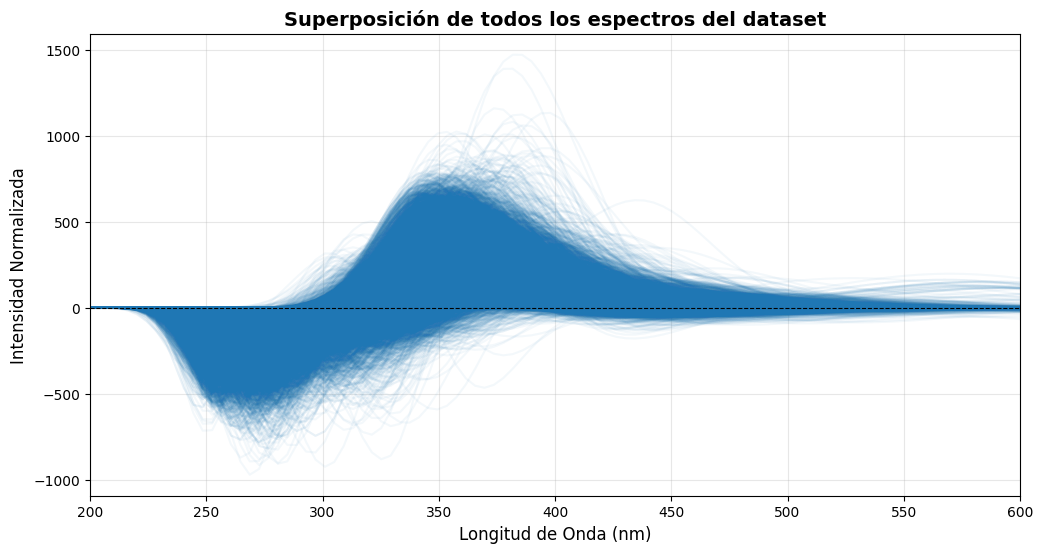

El centro de pico más bajo en todo el dataset está en: 236.2 nm
El centro de pico más alto en todo el dataset está en: 1039.76 nm


In [10]:
import matplotlib.pyplot as plt

# 1. Comprobación Gráfica: Superposición de todos los espectros
plt.figure(figsize=(12, 6))

# Iteramos sobre la matriz Y generada en el paso anterior
# Usamos alpha=0.05 para que cada línea sea casi transparente. 
# Las zonas oscuras indicarán dónde se concentran la mayoría de los picos.
for espectro in Y:
    plt.plot(eje_x_nm, espectro, color='tab:blue', alpha=0.05)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Longitud de Onda (nm)", fontsize=12)
plt.ylabel("Intensidad Normalizada", fontsize=12)
plt.title("Superposición de todos los espectros del dataset", fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xlim(lambda_min, lambda_max)
plt.show()

# 2. Comprobación Numérica: ¿Cuáles son los picos absolutos?
# Buscamos el valor mínimo y máximo de las columnas que contienen las longitudes de onda
picos_min = df[['nm_R1', 'nm_Rmin', 'nm_Rmax']].min().min()
picos_max = df[['nm_R1', 'nm_Rmin', 'nm_Rmax']].max().max()
#Acabo de descubrir que esto no está bien ya que no me dice el pico más bajo y más alto de todo el dataset, sino el que tiene un pico con mas longitud de onda y menos.
#Esto nos indica cuál es el rango real de los datos.
print(f"El centro de pico más bajo en todo el dataset está en: {picos_min} nm")
print(f"El centro de pico más alto en todo el dataset está en: {picos_max} nm")

In [12]:
#Crear Base de datos para Red Neuronal
import pandas as pd

# 1. Crear los nombres de las columnas para que el dataset sea legible
columnas_x = [f'Hammett_Pos_{i}' for i in range(1, 17)]
# Para el espectro, nombramos cada columna con su longitud de onda exacta
columnas_y = [f'Intensidad_{nm:.2f}nm' for nm in eje_x_nm] 

# 2. Unir horizontalmente la matriz X (16) y la matriz Y (100)
# Usamos np.hstack para pegar las columnas una al lado de la otra
datos_completos = np.hstack((X, Y))

# 3. Convertir todo a un DataFrame de Pandas
df_red_neuronal = pd.DataFrame(datos_completos, columns=columnas_x + columnas_y)

# 4. (Opcional pero recomendado) Añadir el nombre de la molécula al principio
# Asumiendo que tu dataframe original 'df' tiene una columna con el nombre (ej. 'Molecula')
if 'Molecula' in df.columns:
    df_red_neuronal.insert(0, 'Molecula', df['Molecula'].values)

# 5. Guardar el resultado final en un nuevo CSV
nombre_archivo_salida = '../Bases de datos/Dataset_envolventes.csv'
df_red_neuronal.to_csv(nombre_archivo_salida, index=False)

print(f"--- ¡Éxito! ---")
print(f"Se ha guardado el archivo '{nombre_archivo_salida}'.")
print(f"Dimensiones del nuevo dataset: {df_red_neuronal.shape[0]} filas x {df_red_neuronal.shape[1]} columnas.")

--- ¡Éxito! ---
Se ha guardado el archivo '../Bases de datos/Dataset_envolventes.csv'.
Dimensiones del nuevo dataset: 13168 filas x 117 columnas.
